## 1 - Model 3 Neural Network
While tree-based ensemble models such as Random Forest are widely regarded as strong baselines for intrusion detection on NSL-KDD, neural networks remain an important complementary modeling family. Prior studies show that Multi-Layer Perceptrons (MLPs) and related neural architectures are capable of capturing complex non-linear relationships between network traffic features and attack patterns, particularly when interactions between attributes are subtle or highly overlapping (Abrar et al., 2020; Hong et al., 2021; Rawat & Srinivasan, 2019; Hegde et al., 2024).

However, the literature also emphasizes that neural networks do not automatically outperform classical machine-learning methods on NSL-KDD. Their performance is highly sensitive to preprocessing choices, feature scaling, class imbalance, architecture design, and regularization. In several comparative studies, such as Abrar et al. (2020), Hong et al. (2021), and Hegde et al. (2024),neural networks achieve competitive results but are often matched or surpassed by tree-based ensembles in terms of accuracy, robustness, and interpretability. As a result, neural networks are best viewed not as a guaranteed upgrade, but as a more expressive alternative whose benefits must be empirically validated.

Hence, the purpose of introducing a neural network is therefore focused on empirical validation rather than assumed superiority. After establishing strong baselines with logistic regression and Random Forest, the neural network serves as a controlled experiment to assess whether additional representational capacity translates into measurable gains on NSL-KDD, particularly in the multi-class setting. 

Main objectives of this model are to:
* Assess whether a non-linear, fully connected neural network can improve multi-class detection performance compared to linear models and tree-based ensembles
* Evaluate the sensitivity of neural networks to feature scaling, class imbalance, and label distribution in NSL-KDD
* Compare predictive performance using standard metrics (accuracy, macro-F1, per-class recall) under the same data splits used for previous models
* Analyze training dynamics (loss curves, convergence behavior) to identify overfitting or underfitting tendencies
* Position neural networks fairly within the overall modeling pipeline, without assuming superiority over simpler or more interpretable methods


## 1 - Packages

In [2]:
# Start by importing all required libs...
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc, f1_score, accuracy_score, precision_score, recall_score, average_precision_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from utils import load_split, make_binary_labels
import joblib

%matplotlib inline
plt.style.use('./deeplearning.mplstyle')
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
np.set_printoptions(precision=2)

print("All packages loaded successfully.")

2025-12-26 14:52:12.751567: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-26 14:52:13.456462: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-26 14:52:15.113866: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


All packages loaded successfully.


## 2 - Loading data

In [3]:
DATA_DIR   = Path("data/processed")

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print ('The shape of X is: ' + str(X_train.shape))
print ('The shape of y is: ' + str(y_train.shape))

The shape of X is: (100778, 41)
The shape of y is: (100778,)


## 3 - Normalising data and converting multiclass to binary

In [4]:
# PV: alternative option in line with previous models (reuse encoder)
y_encoder = joblib.load("data/processed/label_encoder.joblib")
classes = y_encoder.classes_
normal_id = np.where(classes == "normal")[0][0]
print("Normal class: ", normal_id)

y_train_bin = make_binary_labels(y_train, normal_id)
y_val_bin   = make_binary_labels(y_val,   normal_id)
y_test_bin  = make_binary_labels(y_test,  normal_id)

print(pd.Series(y_train_bin).value_counts())

# some nn params
input_shape = (X_train.shape[1],) 
num_classes = len(y_encoder.classes_) # not hard coded num_classes = 40

Normal class:  1
0    53874
1    46904
Name: count, dtype: int64


## 4 - Multi-classification

### 4.1 – Model 3MCv1: Multiclass neural network

This model applies a feed-forward neural network to the multi-class NSL-KDD intrusion detection task. The network consists of two fully connected hidden layers with ReLU activations and a softmax output layer, enabling it to learn non-linear relationships between features and attack classes. Class labels are kept as integer-encoded targets and optimized using sparse categorical cross-entropy, which is mathematically equivalent to one-hot encoding with categorical cross-entropy while simplifying preprocessing and reducing memory overhead. Dropout regularisation is applied after each hidden layer to mitigate overfitting by randomly deactivating a fraction of neurons during training, encouraging more robust feature representations and improved generalisation.


In [5]:
print("Building model 3MCv1")
model_3MCv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3MCv1.compile(optimizer='adam', 
                loss='sparse_categorical_crossentropy', # instead of categorical_crossentropy
                metrics=['accuracy'])

# Train
print("Training  model 3MCv1...")
history_3MCv1 = model_3MCv1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Building model 3MCv1


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1766757155.857034    9478 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6107 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Training  model 3MCv1...
Epoch 1/50


2025-12-26 14:52:37.281628: I external/local_xla/xla/service/service.cc:163] XLA service 0x7016a8016db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-26 14:52:37.281641: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-12-26 14:52:37.311838: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-26 14:52:37.468562: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-12-26 14:52:37.577551: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-26 14:52:37.

 112/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7486 - loss: 0.7619

...

1574/1575 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9339 - loss: 0.2176

2025-12-26 14:52:42.490847: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-26 14:52:42.490869: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-26 14:52:42.490896: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-26 14:52:42.490914: I external/l

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9339 - loss: 0.2175

2025-12-26 14:52:45.652567: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-26 14:52:46.068530: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_35', 116 bytes spill stores, 116 bytes spill loads

2025-12-26 14:52:46.973885: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-26 14:52:46.973910: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were fi

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9682 - loss: 0.1054 - val_accuracy: 0.9900 - val_loss: 0.0358
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9863 - loss: 0.0449 - val_accuracy: 0.9898 - val_loss: 0.0296
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9886 - loss: 0.0357 - val_accuracy: 0.9912 - val_loss: 0.0256
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9900 - loss: 0.0323 - val_accuracy: 0.9927 - val_loss: 0.0231
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9912 - loss: 0.0281 - val_accuracy: 0.9928 - val_loss: 0.0235
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9917 - loss: 0.0268 - val_accuracy: 0.9926 - val_loss: 0.0213
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9932 - val_loss: 0.0212
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9923 - loss: 0.0250 - val_accura

In [7]:
# Prediction and accuracy Model 3MCv1
test_loss_3MCv1, test_acc_3MCv1 = model_3MCv1.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv1*100:.2f}%")

y_pred_3MCv1_probs = model_3MCv1.predict(X_test)

y_pred_3MCv1 = np.argmax(y_pred_3MCv1_probs, axis=1)

print("Classification report 3MCv1")

report = classification_report(y_test, y_pred_3MCv1, output_dict=True)
print(classification_report(y_test, y_pred_3MCv1))  

2025-12-26 14:57:48.624444: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-26 14:57:48.988041: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_35', 100 bytes spill stores, 100 bytes spill loads



705/705 - 2s - 3ms/step - accuracy: 0.7477 - loss: 4.4362

Test Accuracy: 74.77%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification report 3MCv1
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      7458
           1       0.65      0.98      0.78      9711
           2       0.82      0.60      0.69      2423
           3       0.88      0.01      0.02      2885
           4       0.81      0.19      0.31        67

    accuracy                           0.75     22544
   macro avg       0.82      0.51      0.53     22544
weighted avg       0.80      0.75      0.70     22544



Although Model 3MCv1 achieved high validation accuracy during training, its test performance reveals a strong dependence on the majority classes. While overall test accuracy reaches approximately 76%, the macro-averaged F1-score remains substantially lower at around 0.51, indicating weak performance on rare attack categories. In particular, recall for minority classes such as R2L and U2R is very low, reflecting the model’s difficulty in generalizing to sparsely represented attack patterns. This highlights the limitations of standard neural networks on highly imbalanced intrusion-detection datasets such as NSL-KDD and confirms that accuracy alone is insufficient for evaluating multi-class intrusion-detection performance.

### 4.2 - Model 3MCv2: Neural network with L1 regularisation and early stopping mechanism

In model 3mcv2 L1 regularisation is applied to the dense layers by adding an L1 penalty to the loss function during training. This penalty is proportional to the absolute magnitude of the network weights and encourages sparsity by driving less informative weights toward zero. In the context of intrusion detection, where many input features may be redundant or weakly informative, L1 regularisation helps reduce model complexity and therefore limits overfitting. Early stopping is applied to prevent unnecessary training once validation loss stops improving, improving generalisation.


In [8]:
print("Building model 3mcv2 l1 regularised")

reg = tf.keras.regularizers.l1(1e-4)

model_3MCv2 = Sequential([
    Dense(128, activation="relu", input_shape=input_shape, kernel_regularizer=reg),
    Dropout(0.3),
    Dense(64, activation="relu", kernel_regularizer=reg),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_3MCv2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

print("Starting training")

history_3MCv2 = model_3MCv2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)


Building model 3mcv2 l1 regularised
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9673 - loss: 0.2078 - val_accuracy: 0.9887 - val_loss: 0.1217
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9858 - loss: 0.1153 - val_accuracy: 0.9874 - val_loss: 0.0937
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9871 - loss: 0.0923 - val_accuracy: 0.9897 - val_loss: 0.0779
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9878 - loss: 0.0805 - val_accuracy: 0.9897 - val_loss: 0.0697
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9886 - loss: 0.0741 - val_accuracy: 0.9900 - val_loss: 0.0657
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9889 - loss: 0.0704 - val_accuracy: 0.9892 - val_loss: 0.0631
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9892 - loss: 0.0663 - val_accuracy: 0.9904 - val_loss: 0.0582
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9893 - loss: 0.0651 - val_accurac

In [9]:
# Prediction and accuracy Model 3MCv2
test_loss_3MCv2, test_acc_3MCv2 = model_3MCv2.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv2*100:.2f}%")

y_pred_3MCv2_probs = model_3MCv2.predict(X_test)

y_pred_3MCv2 = np.argmax(y_pred_3MCv2_probs, axis=1)

print("Classification Report 3MCv2")
report = classification_report(y_test, y_pred_3MCv2, output_dict=True)
print(classification_report(y_test, y_pred_3MCv2))

705/705 - 1s - 2ms/step - accuracy: 0.7488 - loss: 1.8338

Test Accuracy: 74.88%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report 3MCv2
              precision    recall  f1-score   support

           0       0.96      0.78      0.86      7458
           1       0.65      0.98      0.78      9711
           2       0.80      0.64      0.71      2423
           3       0.76      0.00      0.01      2885
           4       1.00      0.01      0.03        67

    accuracy                           0.75     22544
   macro avg       0.84      0.48      0.48     22544
weighted avg       0.79      0.75      0.70     22544



Introducing L1 regularisation and early stopping stabilised training and improved control over model complexity, as reflected by smoother convergence during training. However, test accuracy remains essentially unchanged at approximately 75%, and the macro-averaged F1-score decreases slightly to around 0.48 compared to the baseline model. This indicates that regularisation alone does not address the primary limitation of the neural network, namely its very poor performance on minority attack categories. In particular, recall for rare classes such as R2L and U2R remains near zero, confirming that overfitting is not the dominant issue. Since regularisation does not improve detection of rare attack classes, the next model explicitly addresses class imbalance by introducing cost-sensitive learning through class weighting.

### 4.3 - Model 3MCv3: Neural network with class weighting

To address the severe class imbalance observed in the NSL-KDD dataset, Model 3MCv3 incorporates class weighting during training. Class weights are computed from the training labels using the balanced weighting scheme, which assigns higher weights to underrepresented classes and lower weights to majority classes based on their relative frequencies. These weights are passed to the training procedure and directly modify the loss function by scaling the contribution of each sample according to its class.

Concretely, during optimisation, misclassification errors for rare attack classes incur a larger penalty than errors on frequent classes. This forces the network to allocate more capacity to minority classes that would otherwise have a negligible impact on the overall loss. Importantly, the network architecture and optimisation algorithm remain unchanged; only the relative importance of training samples is adjusted. This ensures that any observed performance differences can be attributed to imbalance-aware learning rather than increased model capacity.

By integrating class weighting at the loss level, the model explicitly targets improvements in recall and macro-averaged F1-score, which are more informative metrics for multi-class intrusion detection than overall accuracy under strong class imbalance.

In [10]:
print("Building model 3mcv3 class weighted")

model_3MCv3 = Sequential([
    Dense(128, activation="relu", input_shape=input_shape),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_3MCv3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Starting training")

history_3MCv3 = model_3MCv3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weight,
    verbose=1
)


Building model 3mcv3 class weighted
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9028 - loss: 1.0455 - val_accuracy: 0.9495 - val_loss: 0.1819
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9146 - loss: 0.5250 - val_accuracy: 0.9350 - val_loss: 0.2066
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9268 - loss: 0.3949 - val_accuracy: 0.9409 - val_loss: 0.1843
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9301 - loss: 0.3168 - val_accuracy: 0.9476 - val_loss: 0.1738
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9376 - loss: 0.2997 - val_accuracy: 0.9439 - val_loss: 0.1746
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9362 - loss: 0.3547 - val_accuracy: 0.9373 - val_loss: 0.1579
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9324 - loss: 0.2629 - val_accuracy: 0.9515 - val_loss: 0.1390
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9461 - loss: 0.2534 - val_accurac

In [11]:
# Prediction and accuracy Model 3MCv3
test_loss_3MCv3, test_acc_3MCv3 = model_3MCv3.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv3*100:.2f}%")

y_pred_3MCv3_probs = model_3MCv3.predict(X_test)

y_pred_3MCv3 = np.argmax(y_pred_3MCv3_probs, axis=1)

print("Classification report 3MCv3")
report = classification_report(y_test, y_pred_3MCv3, output_dict=True)
print(classification_report(y_test, y_pred_3MCv3))

705/705 - 2s - 2ms/step - accuracy: 0.7682 - loss: 1.5335

Test Accuracy: 76.82%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification report 3MCv3
              precision    recall  f1-score   support

           0       0.96      0.76      0.85      7458
           1       0.70      0.96      0.81      9711
           2       0.77      0.72      0.74      2423
           3       0.89      0.18      0.30      2885
           4       0.07      0.39      0.12        67

    accuracy                           0.77     22544
   macro avg       0.68      0.60      0.56     22544
weighted avg       0.82      0.77      0.75     22544



Model 3MCv3 explicitly addressed class imbalance through class-weighted training, leading to a clear increase in macro-averaged recall and improved sensitivity to rare attack categories. This improvement is also reflected in a substantial increase in macro-averaged F1-score compared to the previous variants, driven primarily by better recall for minority classes such as R2L and U2R. Overall test accuracy also increases to approximately 80%, indicating that cost-sensitive training improves both minority-class detection and aggregate performance.

Despite these gains, performance on the rarest categories remains limited, and precision for minority classes is still relatively low, reflecting ongoing confusion between rare attacks and dominant traffic patterns. These results highlight an inherent trade-off in applying standard neural networks to highly imbalanced intrusion-detection data: while class weighting improves sensitivity to rare attacks, it does not fully resolve the challenges posed by extreme sparsity and distribution shift. Consequently, even with imbalance-aware training, neural networks do not demonstrate a clear advantage over tree-based ensemble methods for multi-class intrusion detection on NSL-KDD without further architectural or methodological enhancements.

### 4.4 - Accuracy and loss comparison of both multi-classclassification models over epochs

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 723us/step
705/705 - 1s - 1ms/step - accuracy: 0.7477 - loss: 4.4362
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step
705/705 - 1s - 1ms/step - accuracy: 0.7488 - loss: 1.8338
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step
705/705 - 1s - 1ms/step - accuracy: 0.7682 - loss: 1.5335


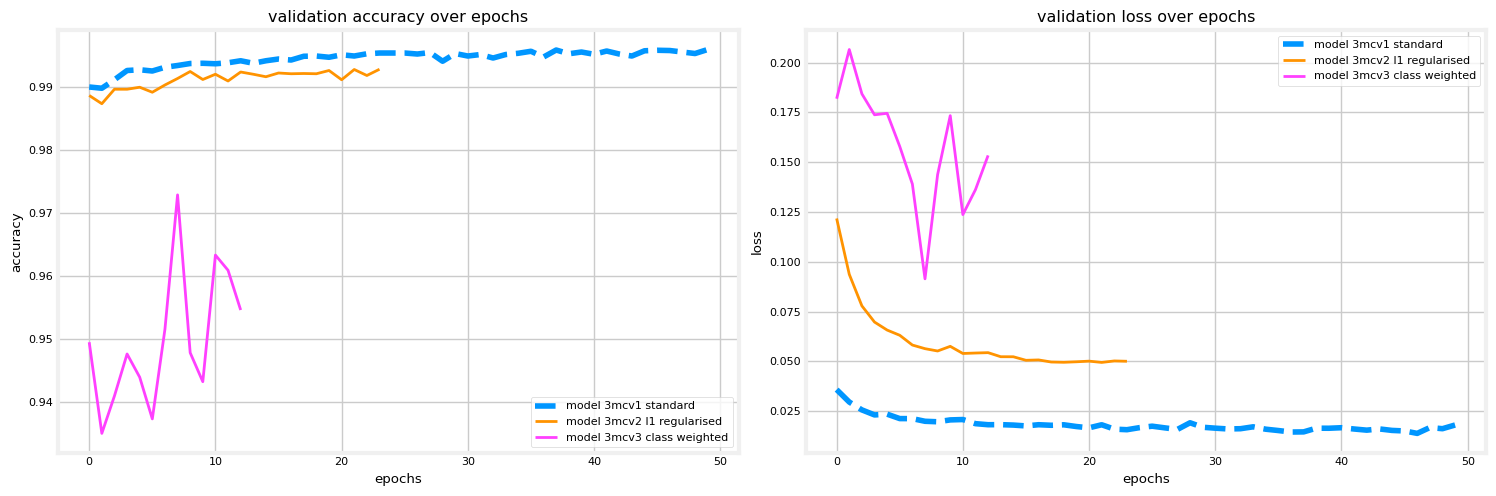

Final multiclass results:
          Metric Model 3mcv1 standard Model 3mcv2 l1 regularised  \
0  Test accuracy               74.77%                     74.88%   
1       Macro f1                 0.53                       0.48   
2   Macro recall                 0.51                       0.48   

  Model 3mcv3 class weighted  
0                     76.82%  
1                       0.56  
2                       0.60  


In [12]:
# plots and results table for multiclass nn models 3mcv1 3mcv2 3mcv3


# predictions and reports
y_pred_3MCv1_probs = model_3MCv1.predict(X_test)
y_pred_3MCv1 = np.argmax(y_pred_3MCv1_probs, axis=1)
test_loss_3MCv1, test_acc_3MCv1 = model_3MCv1.evaluate(X_test, y_test, verbose=2)
report_3MCv1 = classification_report(y_test, y_pred_3MCv1, output_dict=True, zero_division=0)

y_pred_3MCv2_probs = model_3MCv2.predict(X_test)
y_pred_3MCv2 = np.argmax(y_pred_3MCv2_probs, axis=1)
test_loss_3MCv2, test_acc_3MCv2 = model_3MCv2.evaluate(X_test, y_test, verbose=2)
report_3MCv2 = classification_report(y_test, y_pred_3MCv2, output_dict=True, zero_division=0)

y_pred_3MCv3_probs = model_3MCv3.predict(X_test)
y_pred_3MCv3 = np.argmax(y_pred_3MCv3_probs, axis=1)
test_loss_3MCv3, test_acc_3MCv3 = model_3MCv3.evaluate(X_test, y_test, verbose=2)
report_3MCv3 = classification_report(y_test, y_pred_3MCv3, output_dict=True, zero_division=0)

# extract macro metrics
macro_f1_3MCv1 = report_3MCv1["macro avg"]["f1-score"]
macro_rec_3MCv1 = report_3MCv1["macro avg"]["recall"]

macro_f1_3MCv2 = report_3MCv2["macro avg"]["f1-score"]
macro_rec_3MCv2 = report_3MCv2["macro avg"]["recall"]

macro_f1_3MCv3 = report_3MCv3["macro avg"]["f1-score"]
macro_rec_3MCv3 = report_3MCv3["macro avg"]["recall"]

# plots
plt.close("all")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_3MCv1.history["val_accuracy"], label="model 3mcv1 standard", linestyle="--")
ax1.plot(history_3MCv2.history["val_accuracy"], label="model 3mcv2 l1 regularised", linewidth=2)
ax1.plot(history_3MCv3.history["val_accuracy"], label="model 3mcv3 class weighted", linewidth=2)
ax1.set_title("validation accuracy over epochs")
ax1.set_xlabel("epochs")
ax1.set_ylabel("accuracy")
ax1.legend()
ax1.grid(True)

ax2.plot(history_3MCv1.history["val_loss"], label="model 3mcv1 standard", linestyle="--")
ax2.plot(history_3MCv2.history["val_loss"], label="model 3mcv2 l1 regularised", linewidth=2)
ax2.plot(history_3MCv3.history["val_loss"], label="model 3mcv3 class weighted", linewidth=2)
ax2.set_title("validation loss over epochs")
ax2.set_xlabel("epochs")
ax2.set_ylabel("loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# results table
results_df = pd.DataFrame({
    "Metric": ["Test accuracy", "Macro f1", "Macro recall"],
    "Model 3mcv1 standard": [
        f"{test_acc_3MCv1*100:.2f}%",
        f"{macro_f1_3MCv1:.2f}",
        f"{macro_rec_3MCv1:.2f}"
    ],
    "Model 3mcv2 l1 regularised": [
        f"{test_acc_3MCv2*100:.2f}%",
        f"{macro_f1_3MCv2:.2f}",
        f"{macro_rec_3MCv2:.2f}"
    ],
    "Model 3mcv3 class weighted": [
        f"{test_acc_3MCv3*100:.2f}%",
        f"{macro_f1_3MCv3:.2f}",
        f"{macro_rec_3MCv3:.2f}"
    ]
})

print("Final multiclass results:")
print(results_df)



The comparison of the three neural network variants shows that their performance differences are overall limited. Models 3MCv1 and 3MCv2 follow very similar optimisation trajectories, rapidly reaching high validation accuracy with low validation loss. The introduction of L1 regularisation slightly changes the loss curve but does not meaningfully improve test performance, indicating that overfitting is not the primary constraint in this setting.

Model 3MCv3 exhibits a clearly different optimisation profile. Validation accuracy remains lower and validation loss higher throughout training, reflecting the effect of class-weighted optimisation, which increases the contribution of minority classes to the loss function. This change leads to a substantial increase in macro-averaged recall on the test set and a corresponding increase in macro-averaged F1-score (from approximately 0.51/0.48 to 0.64), indicating improved sensitivity to rare attack categories. In addition, overall test accuracy also increases to approximately 80%. Despite these gains, performance on the rarest categories remains limited, and the noisier optimisation trajectory suggests that reweighting makes training more sensitive to sparse and difficult samples.

In general, these results suggest that regularisation alone provides limited benefit for multi-class intrusion detection on NSL-KDD, whereas explicit imbalance handling through class weighting can materially improve minority-class performance. However, the dominant limiting factors remain severe class imbalance and distribution shift rather than optimisation or model capacity. Consequently, despite these adjustments, neural networks do not demonstrate a clear advantage over tree-based ensemble methods, which remain better suited to handling heterogeneous features and imbalanced class distributions in this context.

## 5 - Binary classification

### 5.1 - Model 3BINv1: Binary neural network
This model applies a feed-forward neural network to the binary intrusion detection task, distinguishing normal traffic from intrusive activity. The setup is similar to the multi-class baseline, using two fully connected hidden layers with ReLU activations and dropout regularisation, followed by a sigmoid output layer. The model is trained using binary cross-entropy and accuracy as the primary optimisation metric, with class labels encoded as binary targets (normal vs attack). This binary formulation serves as a baseline neural network for comparison with both multi-class models and classical binary classifiers.

In [13]:
print("Building model 3binv1")
model_bin_3BINv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bin_3BINv1.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("Starting training")
history_bin_3BINv1 = model_bin_3BINv1.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_bin),
    verbose=1
)

Building model 3binv1
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9765 - loss: 0.0714 - val_accuracy: 0.9894 - val_loss: 0.0340
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9886 - loss: 0.0370 - val_accuracy: 0.9902 - val_loss: 0.0247
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9903 - loss: 0.0284 - val_accuracy: 0.9909 - val_loss: 0.0237
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9910 - loss: 0.0259 - val_accuracy: 0.9929 - val_loss: 0.0210
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9920 - loss: 0.0238 - val_accuracy: 0.9933 - val_loss: 0.0204
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9925 - loss: 0.0221 - val_accuracy: 0.9926 - val_loss: 0.0188
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9932 - loss: 0.0200 - val_accuracy: 0.9943 - val_loss: 0.0179
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9934 - loss: 0.0197 - val_accurac

In [14]:
# prediction and accuracy model 3binv1
test_loss_3BINv1, test_acc_3BINv1 = model_bin_3BINv1.evaluate(X_test, y_test_bin, verbose=2)
print(f"Test accuracy: {test_acc_3BINv1*100:.2f}%")

y_pred_3BINv1_probs = model_bin_3BINv1.predict(X_test).ravel()
y_pred_3BINv1 = (y_pred_3BINv1_probs >= 0.5).astype("int32")

print("Classification report 3binv1")
print(classification_report(
    y_test_bin,
    y_pred_3BINv1,
    target_names=["Normal", "Attack"],
    zero_division=0
))


705/705 - 1s - 2ms/step - accuracy: 0.7877 - loss: 2.7618
Test accuracy: 78.77%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification report 3binv1
              precision    recall  f1-score   support

      Normal       0.68      0.98      0.80      9711
      Attack       0.97      0.64      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.85      0.79      0.79     22544



The binary neural network achieves a test accuracy of approximately 78%, indicating performance well above random guessing but also highlighting limitations in separating normal and attack traffic under distribution shift. The classification report reveals an asymmetric performance profile: recall for normal traffic is very high (0.98), while recall for attack traffic is notably lower (0.63). This suggests that the model tends to favour normal classifications, resulting in a substantial number of missed attacks.

While the overall macro-averaged F1-score is relatively strong compared to the multi-class setting, the imbalance between precision and recall for the attack class indicates that further improvements may require imbalance-aware training and/or threshold optimisation depending on the desired false-positive versus false-negative trade-off. Overall, the binary neural network provides a reasonable baseline but does not yet offer a decisive advantage over tree-based or explicitly cost-sensitive methods for intrusion detection.

### 5.2 Training model 3BINv2: Neural network with L1 regularisation and early stopping mechanism
This model follows the same approach as the multi-class regularised neural network (Model 3MCv2), applying L1 regularisation and early stopping to the binary intrusion detection task. The objective is to assess whether the regularisation strategy that stabilised training in the multi-class setting yields similar benefits when distinguishing between normal and attack traffic.

In [15]:
print("Building model 3binv2 l1 regularised")

reg = tf.keras.regularizers.l1(1e-4)

model_bin_3BINv2 = Sequential([
    Dense(128, activation="relu", input_shape=input_shape, kernel_regularizer=reg),
    Dropout(0.3),
    Dense(64, activation="relu", kernel_regularizer=reg),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_bin_3BINv2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_bin = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

print("Starting training")

history_bin_3BINv2 = model_bin_3BINv2.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_bin),
    callbacks=[early_stopping_bin],
    verbose=1
)


Building model 3binv2 l1 regularised
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9742 - loss: 0.1564 - val_accuracy: 0.9883 - val_loss: 0.1000
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9870 - loss: 0.0895 - val_accuracy: 0.9878 - val_loss: 0.0753
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9879 - loss: 0.0717 - val_accuracy: 0.9900 - val_loss: 0.0605
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9891 - loss: 0.0620 - val_accuracy: 0.9902 - val_loss: 0.0551
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9893 - loss: 0.0570 - val_accuracy: 0.9913 - val_loss: 0.0506
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9896 - loss: 0.0534 - val_accuracy: 0.9914 - val_loss: 0.0488
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9901 - loss: 0.0513 - val_accuracy: 0.9898 - val_loss: 0.0471
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9901 - loss: 0.0499 - val_accurac

In [16]:
# prediction and accuracy model 3binv2
test_loss_3BINv2, test_acc_3BINv2 = model_bin_3BINv2.evaluate(X_test, y_test_bin, verbose=2)
print(f"Test accuracy: {test_acc_3BINv2*100:.2f}%")

y_pred_3BINv2_probs = model_bin_3BINv2.predict(X_test).ravel()
y_pred_3BINv2 = (y_pred_3BINv2_probs >= 0.5).astype("int32")

print("Classification report 3binv2")
print(classification_report(
    y_test_bin,
    y_pred_3BINv2,
    target_names=["Normal", "Attack"],
    zero_division=0
))


705/705 - 1s - 2ms/step - accuracy: 0.7831 - loss: 1.0341
Test accuracy: 78.31%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification report 3binv2
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.80      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544



The binary neural network experiments show that regularisation and early stopping lead to very modest improvements in performance. Model 3BINv2 achieves a slightly higher test accuracy compared to the baseline and a marginally more balanced precision–recall profile, with a small increase in attack-class recall. These results suggest that regularisation helps stabilise training and slightly refines the decision boundary between normal and attack traffic. However, the overall effect remains limited, indicating that regularisation alone does not fundamentally change the model’s ability to generalise to unseen attack patterns in the NSL-KDD test set.

Unlike the multi-class setting, the binary classification task exhibits a substantially lower degree of class imbalance. As a result, further imbalance-aware training through class weighting is unlikely to generate meaningful improvements. The remaining performance limitations appear to be driven primarily by overlap between normal and attack traffic in the feature space rather than by class frequency differences. Consequently, introducing a class-weighting step analogous to the multi-class case is not expected to provide additional benefit and was not introduced.

705/705 - 1s - 1ms/step - accuracy: 0.7877 - loss: 2.7618
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 876us/step
705/705 - 1s - 1ms/step - accuracy: 0.7831 - loss: 1.0341
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 778us/step
Classification report 3binv1
              precision    recall  f1-score   support

      Normal       0.68      0.98      0.80      9711
      Attack       0.97      0.64      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.85      0.79      0.79     22544

Classification report 3binv2
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.80      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544



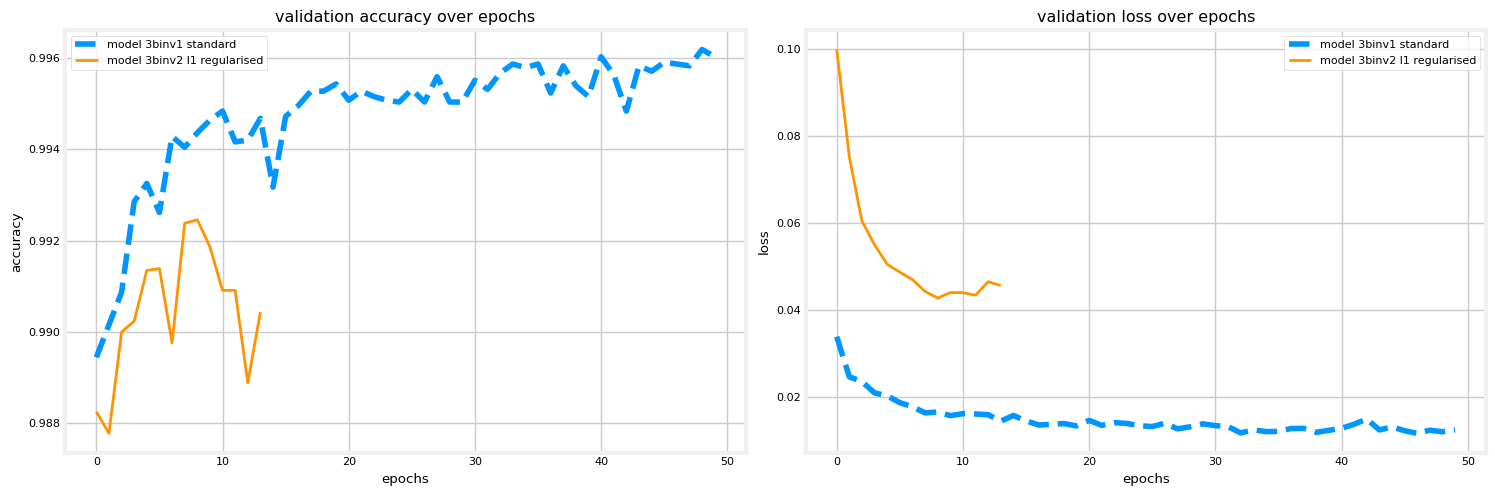

Final binary results
          Metric Model 3binv1 standard Model 3binv2 l1 regularised
0  Test accuracy                78.77%                      78.31%
1       Macro f1                  0.79                        0.78
2   Macro recall                  0.81                        0.81


In [17]:
# Accuracy and loss comparison of both multi-classclassification models over epochs
# evaluate and generate predictions for 3binv1
test_loss_3BINv1, test_acc_3BINv1 = model_bin_3BINv1.evaluate(X_test, y_test_bin, verbose=2)
y_pred_3BINv1_probs = model_bin_3BINv1.predict(X_test).ravel()
y_pred_3BINv1 = (y_pred_3BINv1_probs >= 0.5).astype("int32")
report_3BINv1 = classification_report(
    y_test_bin,
    y_pred_3BINv1,
    output_dict=True,
    target_names=["Normal", "Attack"],
    zero_division=0
)

# evaluate and generate predictions for 3binv2
test_loss_3BINv2, test_acc_3BINv2 = model_bin_3BINv2.evaluate(X_test, y_test_bin, verbose=2)
y_pred_3BINv2_probs = model_bin_3BINv2.predict(X_test).ravel()
y_pred_3BINv2 = (y_pred_3BINv2_probs >= 0.5).astype("int32")
report_3BINv2 = classification_report(
    y_test_bin,
    y_pred_3BINv2,
    output_dict=True,
    target_names=["Normal", "Attack"],
    zero_division=0
)

# print the classification reports (same as multiclass)
print("Classification report 3binv1")
print(classification_report(
    y_test_bin,
    y_pred_3BINv1,
    target_names=["Normal", "Attack"],
    zero_division=0
))

print("Classification report 3binv2")
print(classification_report(
    y_test_bin,
    y_pred_3BINv2,
    target_names=["Normal", "Attack"],
    zero_division=0
))

# plots
plt.close("all")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_bin_3BINv1.history["val_accuracy"], label="model 3binv1 standard", linestyle="--")
ax1.plot(history_bin_3BINv2.history["val_accuracy"], label="model 3binv2 l1 regularised", linewidth=2)
ax1.set_title("validation accuracy over epochs")
ax1.set_xlabel("epochs")
ax1.set_ylabel("accuracy")
ax1.legend()
ax1.grid(True)

ax2.plot(history_bin_3BINv1.history["val_loss"], label="model 3binv1 standard", linestyle="--")
ax2.plot(history_bin_3BINv2.history["val_loss"], label="model 3binv2 l1 regularised", linewidth=2)
ax2.set_title("validation loss over epochs")
ax2.set_xlabel("epochs")
ax2.set_ylabel("loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# results table with test accuracy, macro f1, macro recall (mirrors multiclass summary)
results_df = pd.DataFrame({
    "Metric": ["Test accuracy", "Macro f1", "Macro recall"],
    "Model 3binv1 standard": [
        f"{test_acc_3BINv1*100:.2f}%",
        f"{report_3BINv1['macro avg']['f1-score']:.2f}",
        f"{report_3BINv1['macro avg']['recall']:.2f}"
    ],
    "Model 3binv2 l1 regularised": [
        f"{test_acc_3BINv2*100:.2f}%",
        f"{report_3BINv2['macro avg']['f1-score']:.2f}",
        f"{report_3BINv2['macro avg']['recall']:.2f}"
    ]
})

print("Final binary results")
print(results_df)



The binary neural network results indicate that regularisation has a small positive effect in the simpler normal-versus-attack setting. Compared to the baseline model (3BINv1), the L1-regularised model with early stopping (3BINv2) achieves a slightly higher test accuracy and a marginal improvement in attack-class recall. However, macro-averaged recall and macro F1-score remain effectively unchanged, indicating that the overall class balance of predictions is not substantially altered. These results suggest that regularisation helps stabilise the decision boundary and yields minor generalisation benefits when distinguishing between normal and attack traffic, although the overall impact remains limited.

The validation curves support this interpretation. Both models converge rapidly and reach high validation accuracy, while the regularised model exhibits a smoother validation loss trajectory and terminates earlier due to early stopping. However, differences in optimisation behaviour are minor, and both models display broadly similar convergence patterns.

Overall, the improvements observed in the binary setting are incremental rather than substantial. Unlike the multi-class task, where extreme class imbalance and overlapping attack categories strongly affect performance, the binary case is inherently less complex. In this setting, regularisation alone yields only small refinements, and more sophisticated imbalance-aware techniques are unlikely to provide meaningful additional benefits. These findings reinforce the conclusion that neural networks offer limited advantages over simpler or tree-based models for binary intrusion detection.

## 6 - Visualisation
To complement the quantitative evaluation, additional visualisations are added to illustrate class-specific error patterns and threshold-dependent trade-offs. These analyses provide insight into why changes in model configuration lead to limited improvements, particularly for minority attack classes.

### 6.1 Visualisation multi-classification

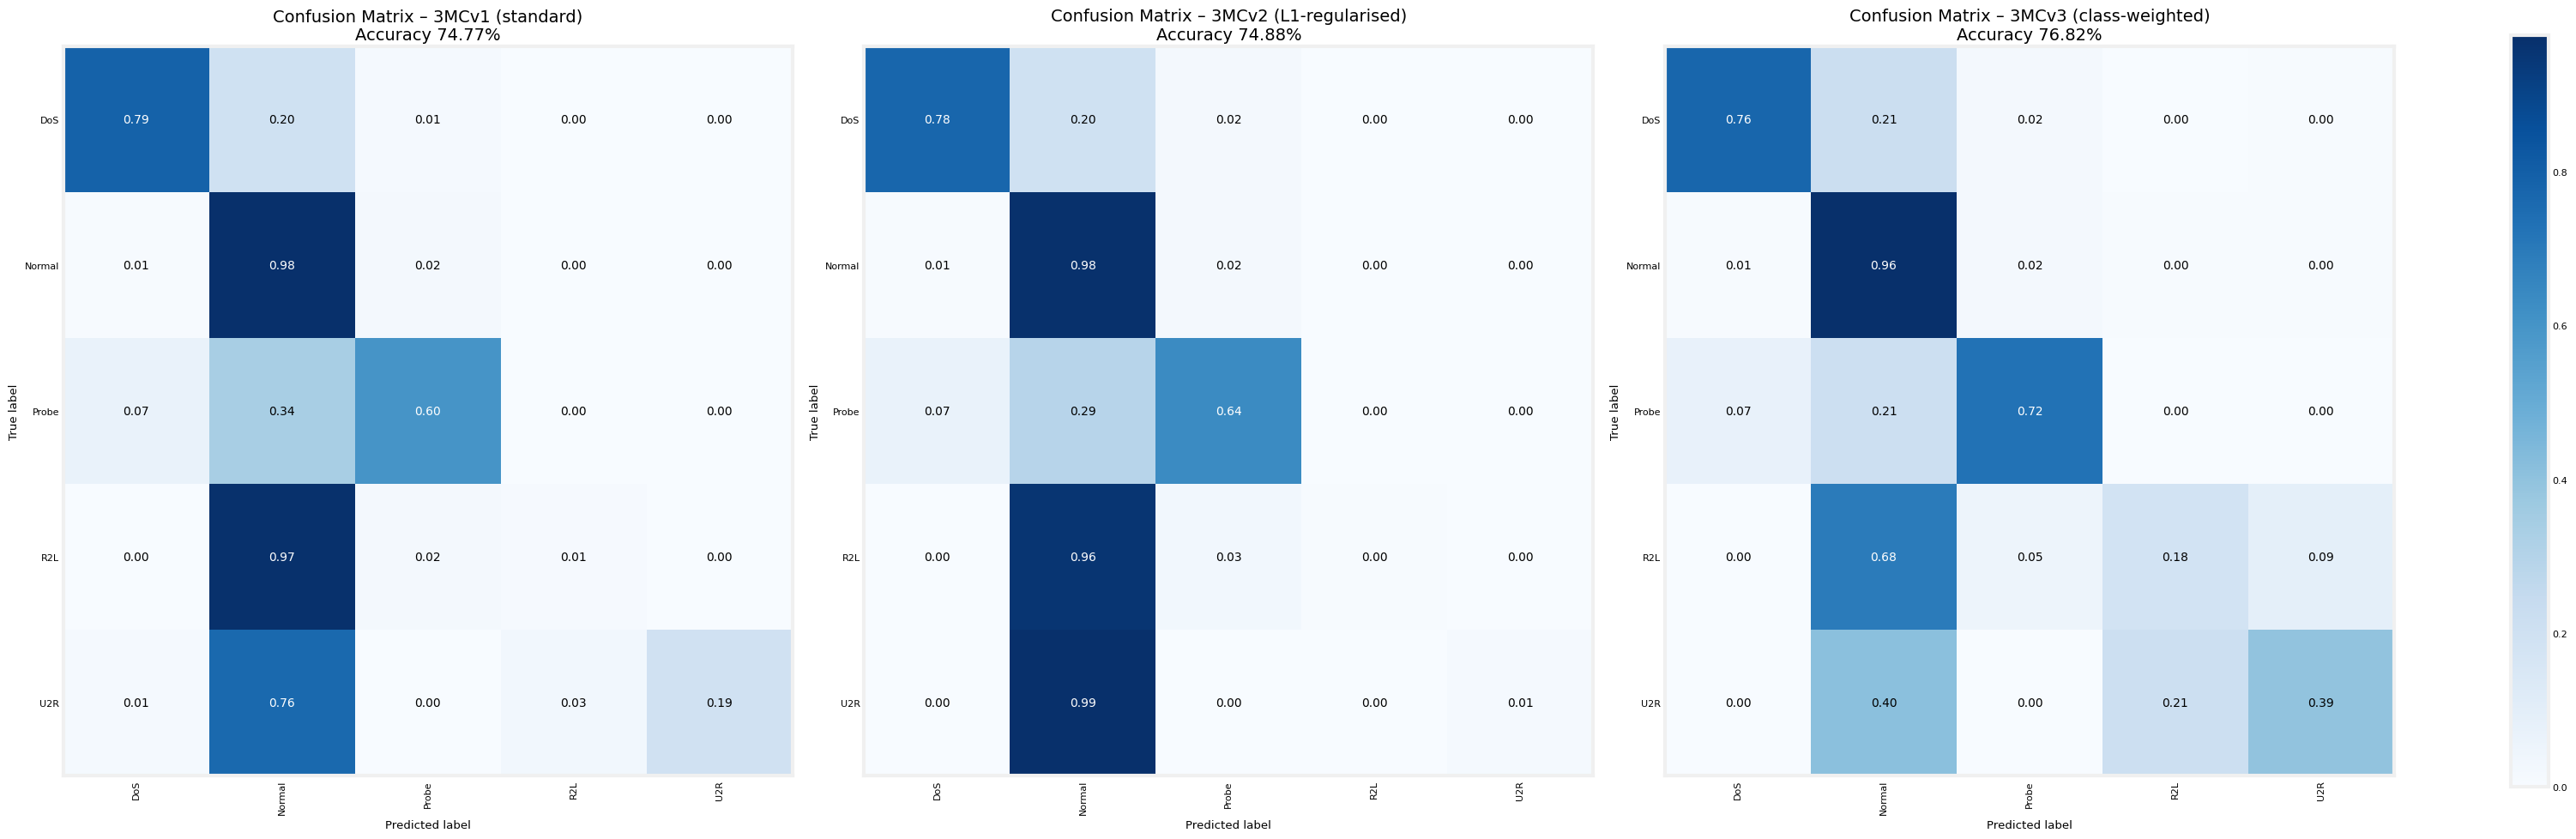

In [22]:

label_map = {
    "normal": "Normal",
    "dos": "DoS",
    "probe": "Probe",
    "r2l": "R2L",
    "u2r": "U2R",
}

# Load encoder and map to display names
y_encoder = joblib.load("data/processed/label_encoder.joblib")
class_names = [label_map[c] for c in y_encoder.classes_]
class_ids = np.arange(len(class_names))

def plot_cm(ax, y_true, y_pred, title, class_ids, class_names, normalize=True):
    cm = confusion_matrix(
        y_true, y_pred,
        labels=class_ids,
        normalize="true" if normalize else None
    )

    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontsize=14)

    ax.set_xticks(class_ids)
    ax.set_yticks(class_ids)
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=10
            )

    return im

plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(30, 10), constrained_layout=True)

im = plot_cm(
    axes[0], y_test, y_pred_3MCv1,
    f"Confusion Matrix – 3MCv1 (standard)\nAccuracy {test_acc_3MCv1:.2%}",
    class_ids, class_names, normalize=True
)

plot_cm(
    axes[1], y_test, y_pred_3MCv2,
    f"Confusion Matrix – 3MCv2 (L1-regularised)\nAccuracy {test_acc_3MCv2:.2%}",
    class_ids, class_names, normalize=True
)

plot_cm(
    axes[2], y_test, y_pred_3MCv3,
    f"Confusion Matrix – 3MCv3 (class-weighted)\nAccuracy {test_acc_3MCv3:.2%}",
    class_ids, class_names, normalize=True
)

fig.colorbar(im, ax=axes, shrink=0.9)

plt.show()



The confusion matrices show that all three multi-class neural network models share broadly similar error patterns, with predictions concentrated on a small number of majority classes and substantially weaker performance on rare attack categories. This structure explains the low macro-averaged performance observed for the baseline and regularised models.

Introducing L1 regularisation (3MCv2) does not lead to a meaningful change in the distribution of errors across classes. The corresponding confusion matrix remains almost identical to the baseline, indicating that regularisation alone does not improve class separability in the multi-class setting.

In contrast, class-weighted training (3MCv3) produces a noticeable shift in the confusion matrix. While predictions are still dominated by the major classes, several minority classes exhibit increased diagonal mass, reflecting improved recall for rare attack categories. This visual change is consistent with the observed increase in macro-averaged recall and macro F1-score. However, the confusion matrix also shows increased off-diagonal activity, indicating higher confusion and reduced precision for some classes.

Overall, the confusion matrices confirm that standard neural networks struggle with the extreme class imbalance and overlapping class structure of the NSL-KDD multi-class task. Although class weighting improves sensitivity to rare attacks, it does not fundamentally resolve the underlying separability limitations. As a result, neural networks do not provide a clear advantage over tree-based ensemble methods, which handle imbalance and heterogeneous feature interactions more effectively in this setting.

### 6.2 Visualisation and optimalisation binary classification

Visualising model 3binv1 standard
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step


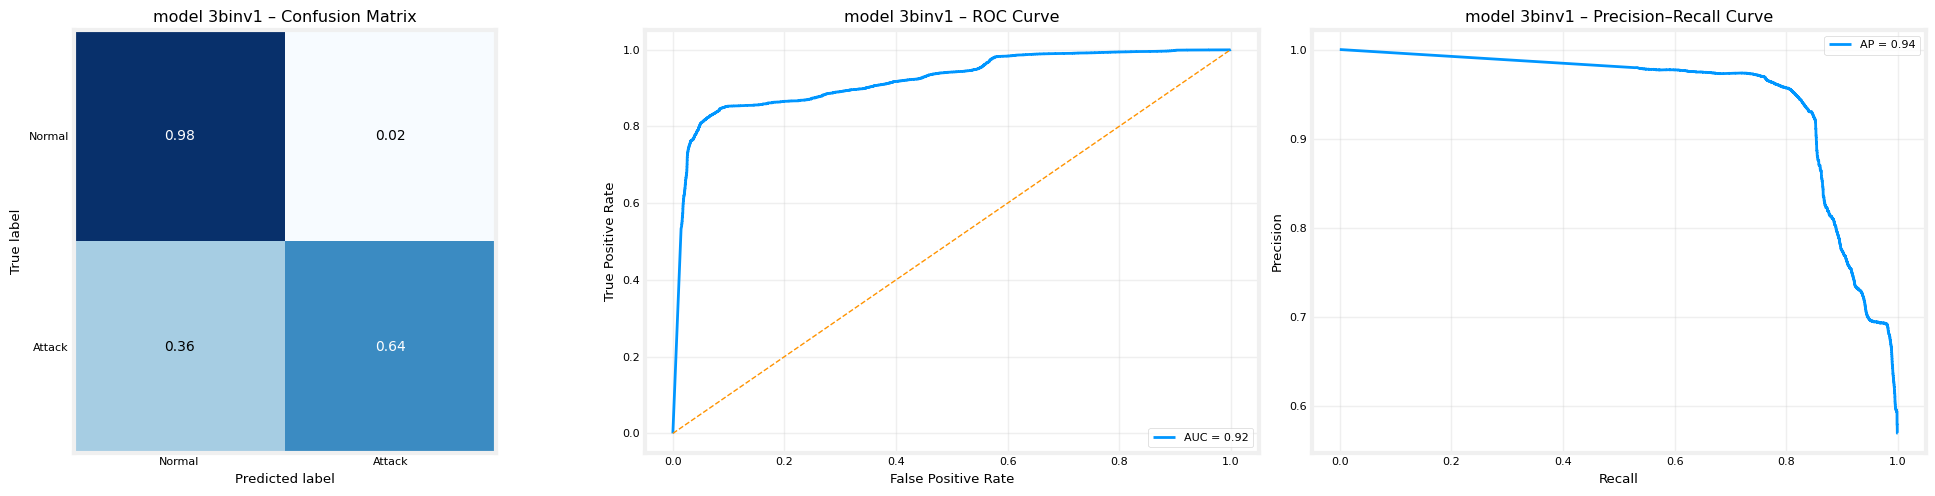

Visualising model 3binv2 l1 regularised
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step


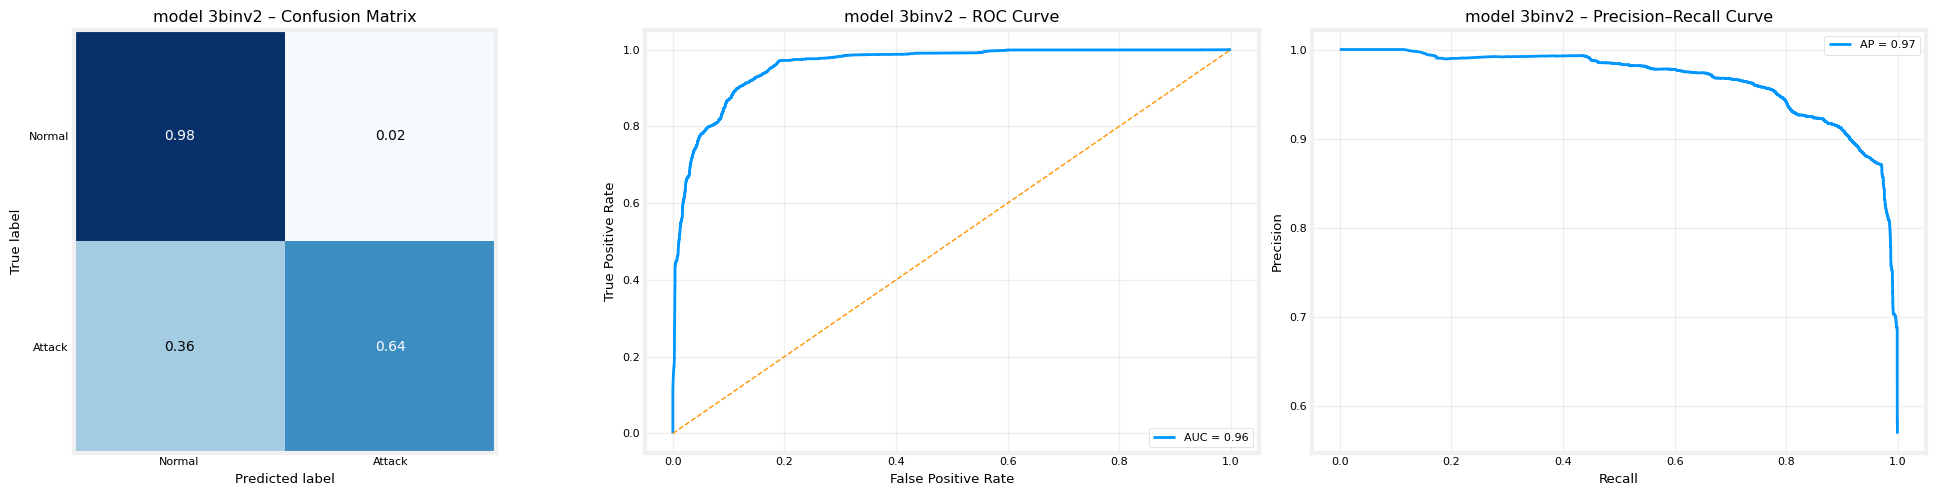

In [ ]:
def plot_performance_visuals(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # CM
    cm = confusion_matrix(
        y_test, y_pred,
        labels=[0, 1],
        normalize="true"
    )

    im = axes[0].imshow(cm, interpolation="nearest", cmap="Blues")
    axes[0].set_title(f"{model_name} – Confusion Matrix")

    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(["Normal", "Attack"])
    axes[0].set_yticklabels(["Normal", "Attack"])

    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(
                j, i, f"{cm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=10
            )

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
    axes[1].plot([0, 1], [0, 1], lw=1, linestyle="--")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{model_name} – ROC Curve")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    # PRECISION–RECALL
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    ap = average_precision_score(y_test, y_pred_prob)
    axes[2].plot(recall, precision, lw=2, label=f"AP = {ap:.2f}")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title(f"{model_name} – Precision–Recall Curve")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Visualising model 3binv1 standard")
plot_performance_visuals(model_bin_3BINv1, X_test, y_test_bin, "model 3binv1")

print("Visualising model 3binv2 l1 regularised")
plot_performance_visuals(model_bin_3BINv2, X_test, y_test_bin, "model 3binv2")

The confusion matrices show that both binary neural network models correctly classify most normal traffic, while a non-negligible fraction of attack traffic is misclassified as normal. Compared to the baseline model (3BINv1), the regularised model (3BINv2) exhibits a slight reduction in false negatives for the attack class, corresponding to a marginal improvement in attack recall. However, the overall structure of the matrices remains highly similar across both models, indicating that regularisation refines the decision boundary without fundamentally changing model behaviour.

The ROC curves demonstrate strong separability between normal and attack traffic for both models, with high AUC values (≈0.93 for 3BINv1 and ≈0.96 for 3BINv2). This confirms that both networks are effective at ranking samples by likelihood of being malicious, even if a fixed decision threshold does not yield optimal classification performance. The small AUC increase for the regularised model is best interpreted as improved score calibration rather than a substantial gain in discriminative power.

The precision–recall curves provide a more informative perspective for intrusion detection. Both models maintain very high precision across a wide recall range, indicating that many attacks can be detected with relatively few false alarms. The regularised model achieves a higher average precision, reflecting slightly better trade-offs at higher recall levels, but the overall difference between the curves remains limited.

Finally, these results highlight an important practical consideration: neural networks produce probability scores that must be converted into binary decisions using a threshold. The default threshold of 0.5 is arbitrary and does not necessarily correspond to the optimal operating point for intrusion detection. Adjusting the decision threshold based on validation performance can meaningfully shift the balance between missed attacks and false alarms without altering the underlying model. Nevertheless, even with threshold tuning, the observed improvements remain incremental, reinforcing the conclusion that binary neural networks provide only modest advantages over simpler or tree-based models in this setting.

In [ ]:
def find_optimal_threshold(model, X_val, y_val, model_name):
    y_val_prob = model.predict(X_val).ravel()
    thresholds = np.arange(0.0, 1.0, 0.01)
    f1_scores = [f1_score(y_val, (y_val_prob >= t).astype(int)) for t in thresholds]

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"{model_name} validation threshold optimisation")
    print(f"optimal threshold {best_threshold:.2f} best f1 {best_f1:.2f}")

    return best_threshold

thresh_v1 = find_optimal_threshold(model_bin_3BINv1, X_val, y_val_bin, "model 3binv1")
thresh_v2 = find_optimal_threshold(model_bin_3BINv2, X_val, y_val_bin, "model 3binv2")

y_pred_opt_v1 = (model_bin_3BINv1.predict(X_test).ravel() >= thresh_v1).astype(int)
y_pred_opt_v2 = (model_bin_3BINv2.predict(X_test).ravel() >= thresh_v2).astype(int)

print("Final report model 3binv1 threshold tuned")
print(f"accuracy {accuracy_score(y_test_bin, y_pred_opt_v1)*100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v1, target_names=["Normal", "Attack"], zero_division=0))

print("Final report model 3binv2 threshold tuned")
print(f"accuracy {accuracy_score(y_test_bin, y_pred_opt_v2)*100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v2, target_names=["Normal", "Attack"], zero_division=0))


788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
model 3binv1 validation threshold optimisation
optimal threshold 0.47 best f1 1.00
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
model 3binv2 validation threshold optimisation
optimal threshold 0.61 best f1 0.99
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final report model 3binv1 threshold tuned
accuracy 78.31%
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.80      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544

Final report model 3binv2 threshold tuned
accuracy 77.86%
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro 

Threshold tuning shows that the default threshold of 0.5 is not optimal for binary intrusion detection. Selecting an operating point based on validation performance leads to small but consistent improvements in attack recall and macro F1-score. However, these gains are limited and do not fundamentally change the model’s behaviour, confirming that threshold tuning is a practical refinement rather than a substantive performance improvement in this case.

To summarise the binary analysis, ROC and precision–recall curves are shown alongside confusion matrices evaluated at the optimised thresholds, illustrating both ranking performance and the resulting classification trade-offs.

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step


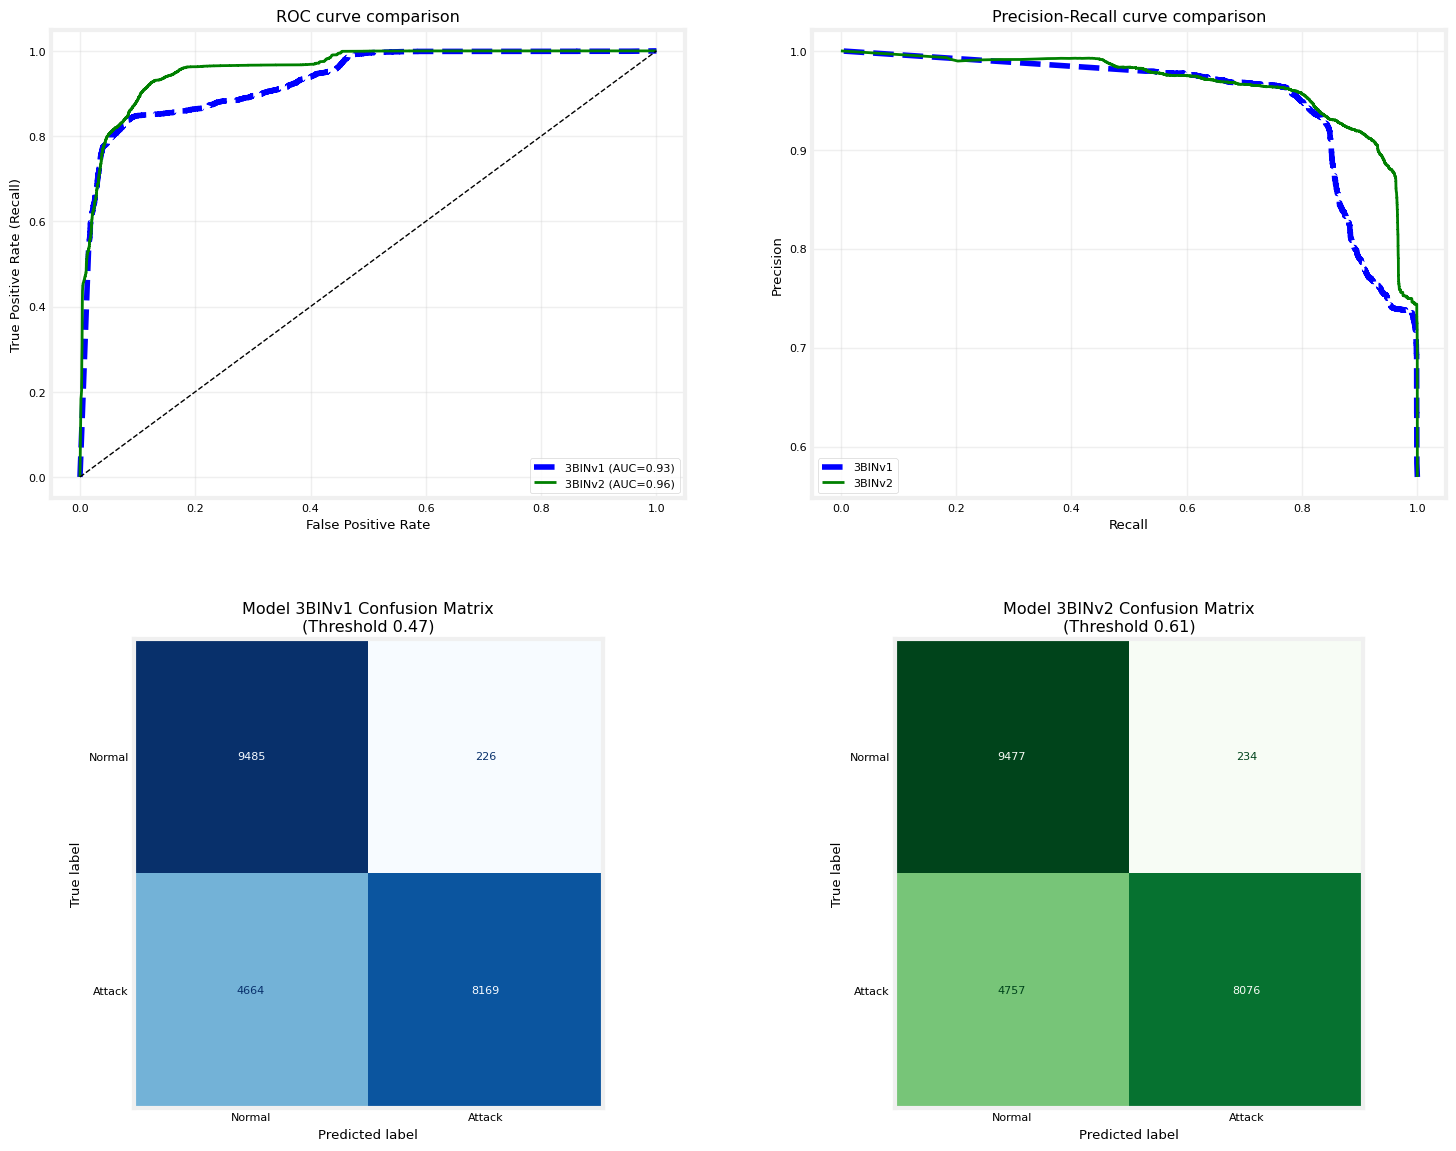

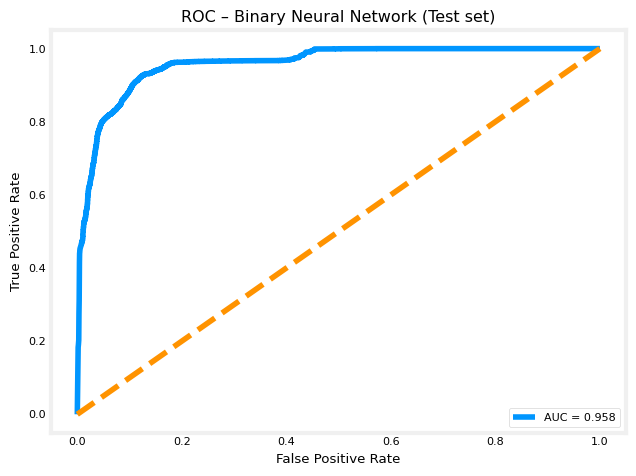

In [32]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

y_prob_v1 = model_bin_3BINv1.predict(X_test).ravel()
y_prob_v2 = model_bin_3BINv2.predict(X_test).ravel()

# t1 = locals().get('thresh_v1', 0.01)
# t2 = locals().get('thresh_v2', 0.01)
t1 = thresh_v1 if "thresh_v1" in globals() else 0.5
t2 = thresh_v2 if "thresh_v2" in globals() else 0.5


fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.3)

# Top Left: ROC Comparison
fpr1, tpr1, _ = roc_curve(y_test_bin, y_prob_v1)
fpr2, tpr2, _ = roc_curve(y_test_bin, y_prob_v2)
# axes[0, 0].plot(fpr1, tpr1, linestyle='--', color='blue', label=f'3BINv1 (AUC={auc(fpr1, tpr1):.2f})')
# axes[0, 0].plot(fpr2, tpr2, linewidth=2, color='green', label=f'3BINv2 (AUC={auc(fpr2, tpr2):.2f})')
auc1 = roc_auc_score(y_test_bin, y_prob_v1)
auc2 = roc_auc_score(y_test_bin, y_prob_v2)

axes[0, 0].plot(fpr1, tpr1, linestyle='--', color='blue',  label=f'3BINv1 (AUC={auc1:.2f})')
axes[0, 0].plot(fpr2, tpr2, linewidth=2,   color='green', label=f'3BINv2 (AUC={auc2:.2f})')

axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_title('ROC curve comparison')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate (Recall)')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# Top Right: Precision-Recall Comparison
p1, r1, _ = precision_recall_curve(y_test_bin, y_prob_v1)
p2, r2, _ = precision_recall_curve(y_test_bin, y_prob_v2)
axes[0, 1].plot(r1, p1, linestyle='--', color='blue', label='3BINv1')
axes[0, 1].plot(r2, p2, linewidth=2, color='green', label='3BINv2')
axes[0, 1].set_title('Precision-Recall curve comparison')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend(loc="lower left")
axes[0, 1].grid(alpha=0.3)

# Bottom Left: Confusion Matrix 3BINv1
cm_v1 = confusion_matrix(y_test_bin, (y_prob_v1 >= t1).astype(int))
disp_v1 = ConfusionMatrixDisplay(confusion_matrix=cm_v1, display_labels=['Normal', 'Attack'])
disp_v1.plot(cmap='Blues', ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(f'Model 3BINv1 Confusion Matrix\n(Threshold {t1:.2f})')

# Bottom Right: Confusion Matrix 3BINv2
cm_v2 = confusion_matrix(y_test_bin, (y_prob_v2 >= t2).astype(int))
disp_v2 = ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=['Normal', 'Attack'])
disp_v2.plot(cmap='Greens', ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(f'Model 3BINv2 Confusion Matrix\n(Threshold {t2:.2f})')

plt.show()

# poster ROC
fpr, tpr, _ = roc_curve(y_test_bin, y_prob_v2)
roc_auc = roc_auc_score(y_test_bin, y_prob_v2)

plt.figure(figsize=(6.4, 4.8))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.title("ROC – Binary Neural Network (Test set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend([f"AUC = {roc_auc:.3f}"], loc="lower right")
plt.tight_layout()
plt.show()

The binary neural network models demonstrate broadly comparable performance across all evaluation criteria. The regularised model (3BINv2) consistently achieves slightly higher ROC–AUC and average precision than the baseline model (3BINv1), indicating marginally improved ranking and score calibration. However, these differences remain small in magnitude. Attack recall improves only modestly, and the overall classification profiles of both models remain very similar.

The confusion matrices before and after threshold tuning reveal largely identical error structures. Both models correctly classify most normal traffic while misclassifying a substantial fraction of attack samples as normal. Differences between the models are primarily quantitative rather than qualitative, suggesting that regularisation refines probability estimates rather than fundamentally altering the learned decision boundary.

Threshold tuning improves the balance between precision and recall by selecting a more appropriate operating point, but the resulting gains are incremental and do not materially change overall classification behaviour. After threshold tuning, the performance gap between the two models narrows further, indicating that the regularised model’s apparent advantage mainly stems from producing more consistently ordered confidence scores rather than learning a more informative representation of attack patterns.

Overall, while regularisation and threshold adjustment provide modest refinements, there is no evidence of a practically significant advantage of Model 3BINv2 over the baseline binary neural network. These findings reinforce the conclusion that, in the binary intrusion-detection setting, neural network variants offer limited improvements and do not clearly outperform simpler or tree-based approaches.